In [1]:
from datasets import Audio, load_from_disk, load_dataset
from extractors import Birdset

import matplotlib.pyplot as plt
import IPython.display as ipd
from IPython.display import display
import numpy as np

import os
import numpy as np
import csv

import torch
import torchaudio

import librosa

import torchaudio.transforms as T

from sam_audio import SAMAudio, SAMAudioProcessor

/home/s.dalal.334/SAM/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/s.dalal.334/SAM/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/s.dalal.334/SAM/.venv/lib/python3.11/site-packages/imagebind/data.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
data = load_dataset("DBD-research-group/BirdSet", "HSN", trust_remote_code=True)

In [3]:
model = "sam-audio-base-tv"

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
sam_model = SAMAudio.from_pretrained(f"facebook/{model}").to(device).eval()
processor = SAMAudioProcessor.from_pretrained(f"facebook/{model}")


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 44431.19it/s]
/home/s.dalal.334/SAM/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/home/s.dalal.334/SAM/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/s.dalal.334/SAM/.venv/lib/python3.11/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Some weights of RobertaModel were not initialized from the 

In [5]:
original_sr = 48_000
new_sr = 32_000

resampler = T.Resample(original_sr, new_sr)

In [6]:
test_data = data["test_5s"].shuffle(seed=42)

In [14]:
clip_idx = 85

In [15]:
example = test_data[clip_idx]['audio']
prompt = "A bird chirping"

In [16]:
inputs = processor(audios=[example['path']], descriptions=[prompt]).to(device) # type: ignore

with torch.inference_mode():
  result = sam_model.separate(inputs)

stripped_path = example['path'].split("/")[-1]
        
processed_audio = result.target[0].detach().cpu()

resampled_waveform = resampler(processed_audio)

print(f"Original audio: {processed_audio}")
print(f"New sample: {resampled_waveform}")

print(f"Original audio length: {processed_audio.shape}")
print(f"New audio length: {resampled_waveform.shape}")

Original audio: tensor([ 3.8072e-04, -1.6396e-05,  4.2991e-04,  ...,  3.5600e-04,
         6.0875e-04,  4.7319e-05])
New sample: tensor([ 0.0002,  0.0002,  0.0003,  ..., -0.0004,  0.0004,  0.0004])
Original audio length: torch.Size([240000])
New audio length: torch.Size([160000])


In [17]:
test_data = test_data.cast_column("audio", Audio(decode=True))

In [18]:
decoded_example = test_data[clip_idx]['audio']

[ 0.00020061  0.0002154   0.00031029 ... -0.0003603   0.00040274
  0.00035365]
Before SAM


After


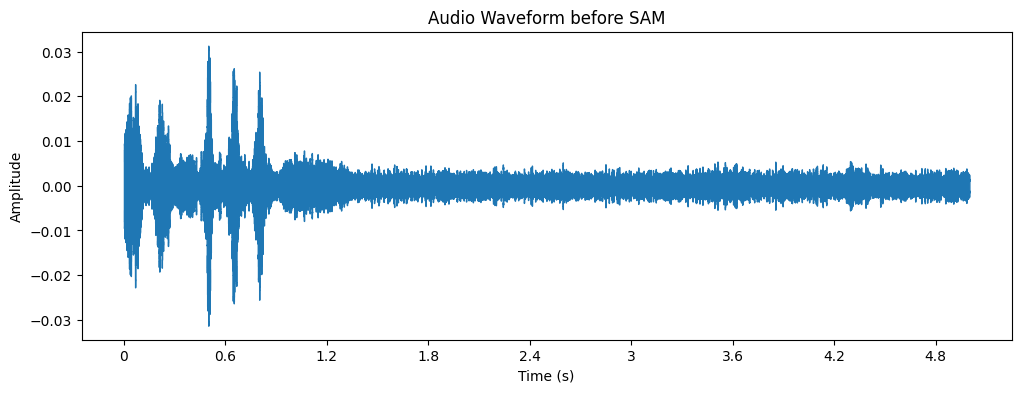

/tmp/ipykernel_1406807/3242425761.py:19: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  librosa.display.specshow(librosa.amplitude_to_db(librosa.stft(y_before), ref=np.max), sr=sr_before, x_axis='time', y_axis='log')


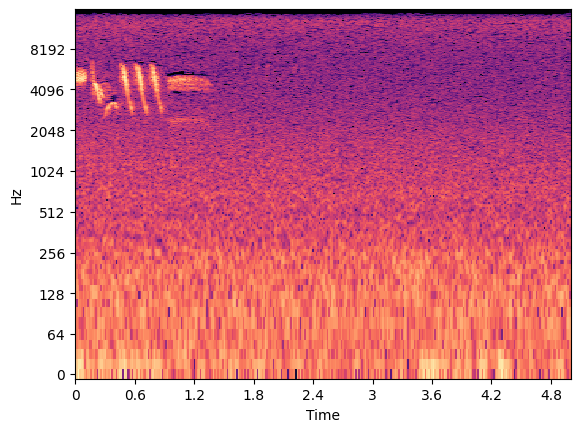

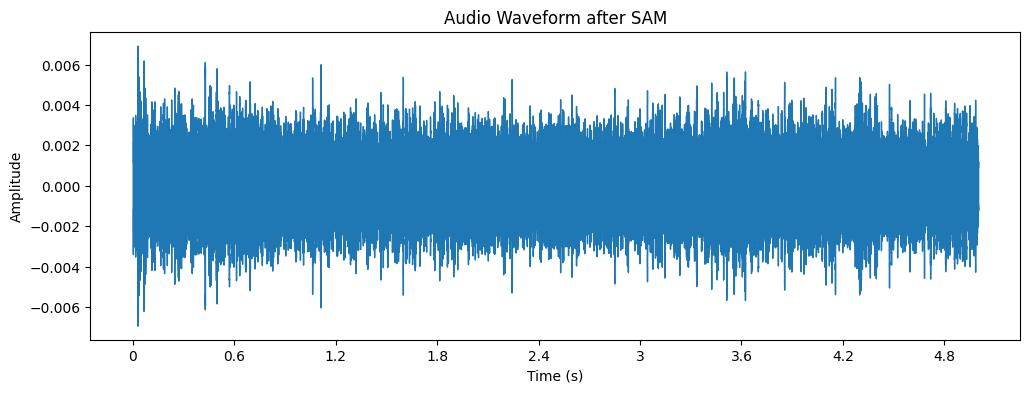

/tmp/ipykernel_1406807/3242425761.py:28: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  librosa.display.specshow(librosa.amplitude_to_db(librosa.stft(y_after), ref=np.max), sr=sr_after, x_axis='time', y_axis='log')


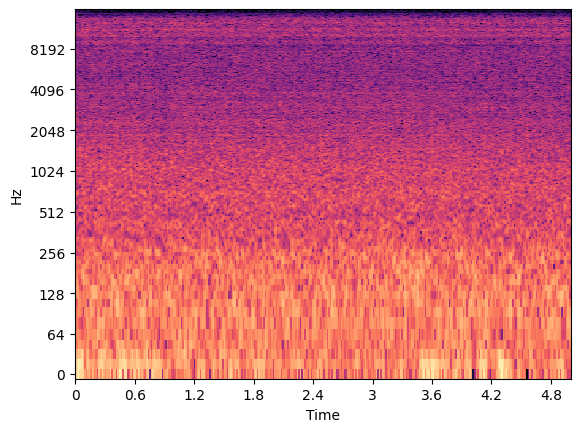

In [19]:
y_before, sr_before = decoded_example['array'], decoded_example["sampling_rate"]

after_nd = resampled_waveform.detach().cpu().numpy()
print(after_nd)
y_after, sr_after = after_nd, new_sr

print("Before SAM")
display(ipd.Audio(data=y_before, rate=sr_before))
print("After")
display(ipd.Audio(data=y_after, rate=sr_after))

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_before, sr=sr_before)
plt.title("Audio Waveform before SAM")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

librosa.display.specshow(librosa.amplitude_to_db(librosa.stft(y_before), ref=np.max), sr=sr_before, x_axis='time', y_axis='log')

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_after, sr=sr_after)
plt.title(f"Audio Waveform after SAM")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

librosa.display.specshow(librosa.amplitude_to_db(librosa.stft(y_after), ref=np.max), sr=sr_after, x_axis='time', y_axis='log')
